In [2]:
# remove the warning massagefrom warnings import filterwarnings
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score

In [3]:
df=pd.read_csv(r"C:\Users\vysha\Downloads\Employers_data.csv")
print(df.head())

   Employee_ID            Name  Age  Gender   Department  Job_Title  \
0            1    Merle Ingram   24  Female  Engineering   Engineer   
1            2      John Mayes   56    Male        Sales  Executive   
2            3    Carlos Wille   21    Male  Engineering     Intern   
3            4  Michael Bryant   30    Male      Finance    Analyst   
4            5   Paula Douglas   25  Female           HR    Analyst   

   Experience_Years Education_Level  Location  Salary  
0                 1          Master    Austin   90000  
1                33          Master   Seattle  195000  
2                 1        Bachelor  New York   35000  
3                 9        Bachelor  New York   75000  
4                 2          Master   Seattle   70000  


In [4]:
print(df.tail())

      Employee_ID            Name  Age  Gender   Department  Job_Title  \
9995         9996   Thomas Rossin   51    Male        Sales  Executive   
9996         9997   Christie King   36  Female        Sales  Executive   
9997         9998   Alfred Keller   57    Male        Sales  Executive   
9998         9999  Margaret Gomez   37  Female  Engineering    Manager   
9999        10000   Joan Sorensen   25  Female        Sales    Analyst   

      Experience_Years Education_Level       Location  Salary  
9995                28          Master         Austin  185000  
9996                 9             PhD  San Francisco  165000  
9997                30             PhD       New York  200000  
9998                14          Master       New York  135000  
9999                 4        Bachelor  San Francisco   70000  


In [5]:
# Check whether there are any missing values
print(df.isna().sum())

Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64


In [6]:
# Check for duplicate rows
df.duplicated().sum()



np.int64(0)

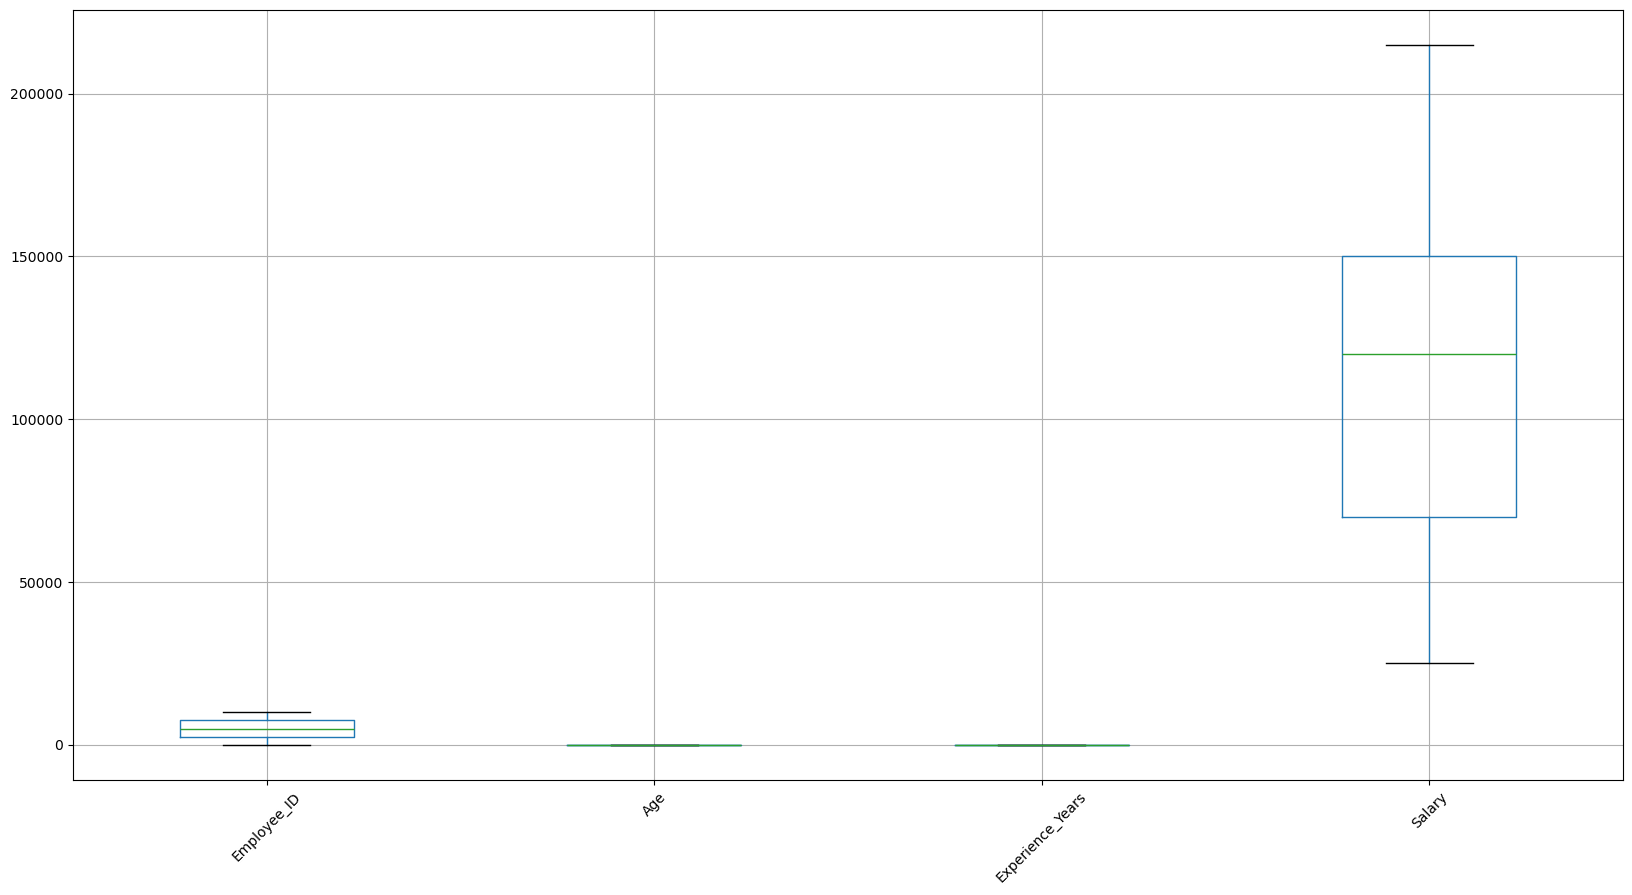

In [7]:
num_cols = df.select_dtypes(include=np.number)
num_cols.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

In [8]:
# Basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None


In [9]:
# Use summary statistics to understand distributions.
print(df.describe())


       Employee_ID           Age  Experience_Years         Salary
count  10000.00000  10000.000000      10000.000000   10000.000000
mean    5000.50000     35.455900         12.370900  115381.500000
std     2886.89568     10.000213          9.148951   46066.139047
min        1.00000     21.000000          0.000000   25000.000000
25%     2500.75000     27.000000          5.000000   70000.000000
50%     5000.50000     34.000000         10.000000  120000.000000
75%     7500.25000     43.000000         19.000000  150000.000000
max    10000.00000     60.000000         37.000000  215000.000000


“Employee_ID and Name were dropped because they are unique identifiers with no predictive relationship to salary and would only introduce noise into the model.”

In [11]:
#drop id and name
df = df.drop(columns=["Employee_ID", "Name"])

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\vysha\anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\vysha\AppData\Local\Temp\ipykernel_9400\1871921754.py", line 2, in <module>
    df = df.drop(columns=["Employee_ID", "Name"])
  File "c:\Users\vysha\anaconda3\lib\site-packages\pandas\core\frame.py", line 5603, in drop
    return super().drop(
  File "c:\Users\vysha\anaconda3\lib\site-packages\pandas\core\generic.py", line 4810, in drop
    obj = obj._drop_axis(labels, axis, level=level, errors=errors)
  File "c:\Users\vysha\anaconda3\lib\site-packages\pandas\core\generic.py", line 4852, in _drop_axis
    new_axis = axis.drop(labels, errors=errors)
  File "c:\Users\vysha\anaconda3\lib\site-packages\pandas\core\indexes\base.py", line 7136, in drop
    raise KeyError(f"{labels[mask].tolist()} not found in axis")
KeyError: "['Employee_ID', 'Name'] not found in axis"

During han

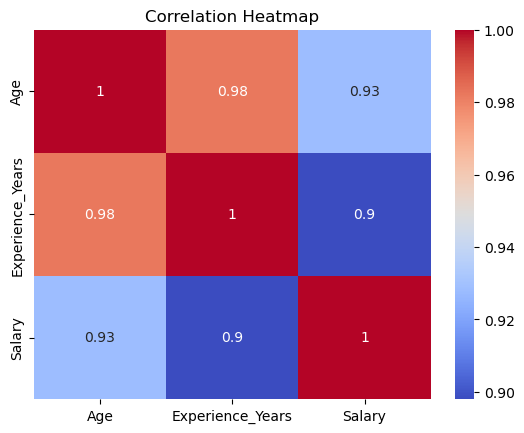

In [17]:
#sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
#plt.title('Correlation Heatmap')
#plt.show()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
X = df.drop(columns=["Salary", "Age"])   # Age dropped due to multicollinearity
y = df["Salary"]

In [14]:
#from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LogisticRegression
#x=[[1,2],[2,3],[3,4],[4,5]]
#y=[0,1,0,1]
#x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#model=LogisticRegression()
#model.fit(x_train,y_train)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
num_cols = ["Experience_Years"]
cat_cols = ["Gender", "Department", "Job_Title", "Education_Level", "Location"]
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols),("cat", OneHotEncoder(drop="first"), cat_cols)])


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", LinearRegression())])
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#Which employee has the highest salary?
highest_salary = df.nlargest(1, 'Salary')
print("Employee with the Highest Salary:")
print(highest_salary[['Employee_ID', 'Name', 'Department', 'Job_Title', 'Salary']])

In [18]:
from sklearn.metrics import r2_score

# Predict values
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = r2_score(y_test, y_pred)

print("Model Accuracy (R2 Score):", accuracy)

Model Accuracy (R2 Score): 0.9917630416473503


In [19]:
#What is the average salary by department?
avg_salary = df.groupby('Department')['Salary'].mean()
print("Average Salary by Department:")
print(avg_salary)


Average Salary by Department:
Department
Engineering     90680.332739
Finance        130376.175549
HR             126400.602410
Marketing      101734.571600
Product        116676.334107
Sales          127309.766327
Name: Salary, dtype: float64


In [ ]:
#Lowest salary per department
lowest_per_dept = df.loc[df.groupby('Department')['Salary'].idxmin()]
print("Lowest Paid Employee in Each Department:")
print(lowest_per_dept[['Department', 'Name', 'Job_Title', 'Salary']])


In [ ]:
df=pd.read_csv(r"C:\Users\vysha\Downloads\Employers_data.csv")
print(df.head())